Этот проект не раотает, т.к. не стаивться тензерфлоу

В этом файле будем основываться на проект https://www.geeksforgeeks.org/multivariate-time-series-forecasting-with-lstms-in-keras/?__ya_mt_enable_static_translations=1

И на старый проект p1 с нира

проект с реконвертациией минимакс нормализации LSTM от сюда --> https://www.geeksforgeeks.org/time-series-forecasting-using-pytorch/

интерсно, что в этом проекте применяется минимакснормализация, но потом значения предсказываются ( либо конвертируются) в нормальную цену 

In [5]:
import datetime
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import KernelPCA
import numpy as np
import pandas as pd
import math
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
tf.random.set_seed(99)
tf.compat.v1.enable_eager_execution() #используете Eager execution (режим немедленного выполнения
from sklearn.metrics import mean_squared_error

In [6]:
# Здесь НАЧНЁМ подготваливать свои данные
dataFrame = pd.read_csv('file_for_input/all_hour/SBER_tradestats_test_hour.csv')
dataFrame['tradedate'] = dataFrame['tradedate'] + '-' + dataFrame['tradetime_hour'].astype(str)
dataFrame = dataFrame.drop('tradetime_hour', axis=1)
dataFrame = dataFrame.rename(columns={'tradedate': 'Date'})
dataFrame = dataFrame.rename(columns={'pr_close_hour': 'Close'})
dataFrame = dataFrame.rename(columns={'pr_open_hour': 'Open'})
print(dataFrame)
print(dataFrame.columns)
print(dataFrame.head(n=2))
print("KONEC -----------------------------------")

# Здесь ЗАКОНЧИМ подготваливать свои данные

               Date       vol           val  trades  trades_b  trades_s  \
0     2020-01-03-10  393181.0  1.008007e+09  6584.0    3382.0    3202.0   
1     2020-01-03-11  404569.0  1.037253e+09  5842.0    3062.0    2780.0   
2     2020-01-03-12  426476.0  1.097535e+09  6513.0    3814.0    2699.0   
3     2020-01-03-13  313630.0  8.048766e+08  3940.0    1625.0    2315.0   
4     2020-01-03-14  459403.0  1.174223e+09  5677.0    1791.0    3886.0   
...             ...       ...           ...     ...       ...       ...   
8520  2023-10-31-14  259768.0  6.953090e+08  5298.0    3028.0    2270.0   
8521  2023-10-31-15  204836.0  5.495618e+08  4552.0    2736.0    1816.0   
8522  2023-10-31-16  151698.0  4.074511e+08  3337.0    1681.0    1656.0   
8523  2023-10-31-17  117210.0  3.142460e+08  3731.0    1694.0    2037.0   
8524  2023-10-31-18  182162.0  4.892960e+08  3102.0    1896.0    1206.0   

            val_b        val_s     vol_b     vol_s    Open   Close  \
0     530078472.0  477928530.

In [7]:
#Data preprocessing
imputer = SimpleImputer(missing_values=np.nan) # Handling missing values
date_df =dataFrame['Date'] # Сохранили на будущее дату
dataFrame.drop(columns=['Date'], inplace=True)
dataFrame = pd.DataFrame(imputer.fit_transform(dataFrame), columns=dataFrame.columns)
dataFrame = dataFrame.reset_index(drop=True)
# Applying feature scaling
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(dataFrame.to_numpy())
df_scaled = pd.DataFrame(df_scaled, columns=list(dataFrame.columns))
target_scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled[['Open', 'Close']] = target_scaler.fit_transform(dataFrame[['Open', 'Close']].to_numpy())
df_scaled = df_scaled.astype(float)
# df_scaled = dataFrame.astype(float)

In [10]:
#Также выделяем столько же дат в ДФ с датами
date_temp=dataFrame['tradedate']
n = int(len(date_temp) * 0.80)
# выбираем последние n строк
date_df_test = date_temp.iloc[-n:]
date_df= date_temp.iloc[:-n]

KeyError: 'tradedate'

In [24]:
date_df

0       2020-01-03-10
1       2020-01-03-11
2       2020-01-03-12
3       2020-01-03-13
4       2020-01-03-14
            ...      
1700    2020-10-05-18
1701    2020-10-06-10
1702    2020-10-06-11
1703    2020-10-06-12
1704    2020-10-06-13
Name: Date, Length: 1705, dtype: object

In [25]:
# Здесь начнём добавлять тестовую выборку
# вычисляем количество строк, которое соответствует 25% от общего количества строк
n = int(len(dataFrame) * 0.80)
# выбираем последние n строк
df_test = dataFrame.iloc[-n:]
dataFrame= dataFrame.iloc[:-n] # Убираем последние n% строк из основного датасета
# Здесь нЗакончим создавать тестовую выборку

In [26]:
date_df

0       2020-01-03-10
1       2020-01-03-11
2       2020-01-03-12
3       2020-01-03-13
4       2020-01-03-14
            ...      
1700    2020-10-05-18
1701    2020-10-06-10
1702    2020-10-06-11
1703    2020-10-06-12
1704    2020-10-06-13
Name: Date, Length: 1705, dtype: object

In [27]:
date_df

0       2020-01-03-10
1       2020-01-03-11
2       2020-01-03-12
3       2020-01-03-13
4       2020-01-03-14
            ...      
1700    2020-10-05-18
1701    2020-10-06-10
1702    2020-10-06-11
1703    2020-10-06-12
1704    2020-10-06-13
Name: Date, Length: 1705, dtype: object

In [28]:
# Single step dataset preparation
def singleStepSampler(df, window):
	xRes = []
	yRes = []
	for i in range(0, len(df) - window):
		res = []
		for j in range(0, window):
			r = []
			for col in df.columns:
				r.append(df[col][i + j])
			res.append(r)
		xRes.append(res)
		yRes.append(df[['Open', 'Close']].iloc[i + window].values)
	return np.array(xRes), np.array(yRes)


In [29]:
	# Dataset splitting
SPLIT = 0.85
(xVal, yVal) = singleStepSampler(df_scaled, 20) # было (xVal, yVal) = singleStepSampler(df_scaled, 20)
print("Кол-во данных после сплитинга ",len(xVal),len(yVal))


X_final_test = xVal[int(SPLIT * len(xVal)):]
y_final_test = yVal[int(SPLIT * len(yVal)):]
xVal = xVal[:int(SPLIT * len(xVal))]
yVal = yVal[:int(SPLIT * len(yVal))]
print("длина X_final_test,y_final_test ",len(X_final_test),len(y_final_test))
print("Кол-во данных после X_final_test ",len(xVal),len(yVal))


X_train = xVal[:int(SPLIT * len(xVal))]
y_train = yVal[:int(SPLIT * len(yVal))]
X_test = xVal[int(SPLIT * len(xVal)):]
y_test = yVal[int(SPLIT * len(yVal)):]
print("(обычное обучение)Кол-во данных  X_train, y_train ",len(X_train),len(y_train))
print("(обычное обучение)Кол-во данных  X_test, y_test ",len(X_test),len(y_test))


Кол-во данных после сплитинга  8505 8505
длина X_final_test,y_final_test  1276 1276
Кол-во данных после X_final_test  7229 7229
(обычное обучение)Кол-во данных  X_train, y_train  6144 6144
(обычное обучение)Кол-во данных  X_test, y_test  1085 1085


In [30]:
multivariate_lstm = keras.Sequential()
multivariate_lstm.add(keras.layers.LSTM(20, input_shape=(X_train.shape[1], X_train.shape[2])))
multivariate_lstm.add(keras.layers.Dropout(0.2))
multivariate_lstm.add(keras.layers.Dense(2, activation='linear'))
multivariate_lstm.compile(loss='mean_squared_error', metrics=['mae'], optimizer='adam') # Было: metrics=['mae']
multivariate_lstm.summary()

C:\TRADE_LapTop\KanNootebook\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 20)             │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,762 (10.79 KB)

 Trainable params: 2,762 (10.79 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = multivariate_lstm.fit(X_train, y_train, epochs=50)#,validation_split=0.4

Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0284 - mae: 0.1168
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0073 - mae: 0.0609
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053 - mae: 0.0517
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037 - mae: 0.0433
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034 - mae: 0.0412
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028 - mae: 0.0376
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024 - mae: 0.0346
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021 - mae: 0.0322
Epoch 9/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019 - mae: 0.0306
Epoch 10/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016 - mae: 0.0287
Epoch 11/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - mae: 0.0272
Epoch 12/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0013 - mae: 0.0255
Epoch 13/50
192/192 ━━━━━

In [32]:
# Оценка исходной точности модели
y_pred = multivariate_lstm.predict(X_test)
baseline_mse = mean_squared_error(y_test, y_pred)
print(f"Baseline MSE: {baseline_mse}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Baseline MSE: 1.4465221029718816e-05


In [33]:
dataFrame.head(2)

,vol,val,trades,trades_b,trades_s,val_b,val_s,vol_b,vol_s,Open,Close,pr_high_hour,pr_low_hour
0,393181.0,1.008007e+09,6584.0,3382.0,3202.0,530078472.0,477928530.0,206729.0,186452.0,255.97,256.22,256.97,255.83
1,404569.0,1.037253e+09,5842.0,3062.0,2780.0,541698592.0,495554901.0,211222.0,193347.0,256.15,256.68,256.90,255.52


In [34]:
date_df

0       2020-01-03-10
1       2020-01-03-11
2       2020-01-03-12
3       2020-01-03-13
4       2020-01-03-14
            ...      
1700    2020-10-05-18
1701    2020-10-06-10
1702    2020-10-06-11
1703    2020-10-06-12
1704    2020-10-06-13
Name: Date, Length: 1705, dtype: object

In [35]:
# Reload the data with the date index
dataFrame = pd.read_csv('file_for_input/all_hour/SBER_tradestats_test_hour.csv') # Assuming the CSV file contains a 'Date' column
dataFrame['tradedate'] = pd.to_datetime(date_df['tradedate'])
dataFrame.set_index('tradedate', inplace=True)

KeyError: 'tradedate'

In [52]:
dataFrame.head(2)

,tradetime_hour,vol,val,trades,trades_b,trades_s,val_b,val_s,vol_b,vol_s,pr_open_hour,pr_close_hour,pr_high_hour,pr_low_hour
tradedate,,,,,,,,,,,,,,
2020-01-03,10,393181.0,1.008007e+09,6584.0,3382.0,3202.0,530078472.0,477928530.0,206729.0,186452.0,255.97,256.22,256.97,255.83
2020-01-03,11,404569.0,1.037253e+09,5842.0,3062.0,2780.0,541698592.0,495554901.0,211222.0,193347.0,256.15,256.68,256.90,255.52


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step


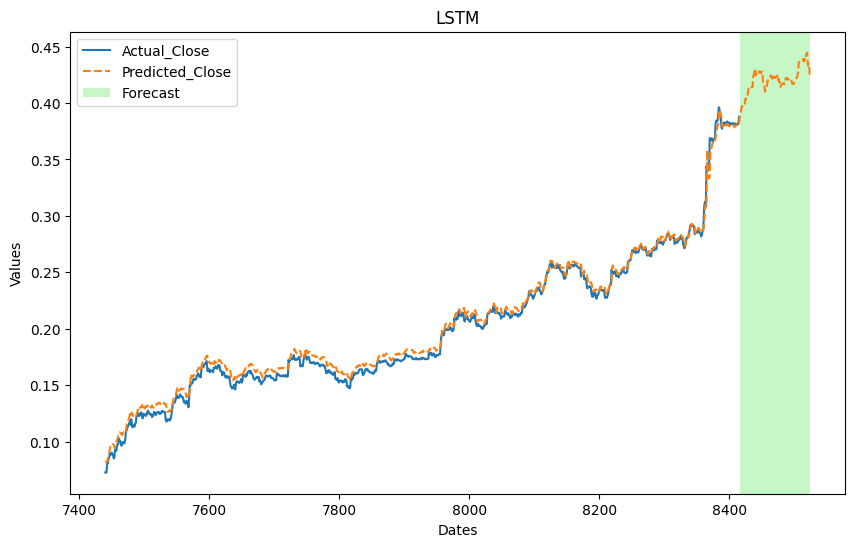

In [22]:
# Forecast Plot with Dates on X-axis
predicted_values = multivariate_lstm.predict(X_test)

d = {
	'Predicted_Open': predicted_values[:, 0],
	'Predicted_Close': predicted_values[:, 1],
	'Actual_Open': y_test[:, 0],
	'Actual_Close': y_test[:, 1],
}

d = pd.DataFrame(d)
d.index = dataFrame.index[-len(y_test):] # Assigning the correct date index

fig, ax = plt.subplots(figsize=(10, 6))
# highlight the forecast
highlight_start = int(len(d) * 0.9)
highlight_end = len(d) - 1 # Adjusted to stay within bounds
# Plot the actual values
plt.plot(d[['Actual_Close']][:highlight_start], label=['Actual_Close'])

# Plot predicted values with a dashed line
plt.plot(d[['Predicted_Close']], label=['Predicted_Close'], linestyle='--')

# Highlight the forecasted portion with a different color
plt.axvspan(d.index[highlight_start], d.index[highlight_end], facecolor='lightgreen', alpha=0.5, label='Forecast')

#  ГРАфик предсказаных значений
plt.title('LSTM')
plt.xlabel('Dates')
plt.ylabel('Values')
ax.legend()
plt.show()